### **Importing Packages**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectKBest, f_regression
from scipy import stats
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

import xgboost as xgb

import mlflow
import mlflow.sklearn
import dagshub

import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
import mlflow

os.environ['MLFLOW_TRACKING_USERNAME'] = 'ejoba22'
os.environ['MLFLOW_TRACKING_PASSWORD'] = 'a7173ed993c5e34d5a5b3661dc4380bb976e814f'

mlflow.set_tracking_uri("https://dagshub.com/ejoba22/House-Prices.mlflow")
mlflow.set_experiment("house-prices")

print("Connected!")

Connected!


In [3]:
def show_all(df):
    with pd.option_context('display.max_rows', 100, 'display.max_columns', 100):
        display(df)

### **Importing Data**

In [4]:
train = pd.read_csv('house-prices-advanced-regression-techniques/train.csv')
test = pd.read_csv('house-prices-advanced-regression-techniques/test.csv')
data = pd.concat((train, test)).reset_index(drop=True)
data.drop(['SalePrice'], axis=1, inplace=True)

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (1460, 81)
Test shape: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
train.shape, test.shape

((1460, 81), (1459, 80))

### **Data Exploration And Visualization**

In [6]:
print(train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [7]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [8]:
train.keys()

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [9]:
train.dtypes[train.dtypes != object]

Id                 int64
MSSubClass         int64
LotFrontage      float64
LotArea            int64
OverallQual        int64
OverallCond        int64
YearBuilt          int64
YearRemodAdd       int64
MasVnrArea       float64
BsmtFinSF1         int64
BsmtFinSF2         int64
BsmtUnfSF          int64
TotalBsmtSF        int64
1stFlrSF           int64
2ndFlrSF           int64
LowQualFinSF       int64
GrLivArea          int64
BsmtFullBath       int64
BsmtHalfBath       int64
FullBath           int64
HalfBath           int64
BedroomAbvGr       int64
KitchenAbvGr       int64
TotRmsAbvGrd       int64
Fireplaces         int64
GarageYrBlt      float64
GarageCars         int64
GarageArea         int64
WoodDeckSF         int64
OpenPorchSF        int64
EnclosedPorch      int64
3SsnPorch          int64
ScreenPorch        int64
PoolArea           int64
MiscVal            int64
MoSold             int64
YrSold             int64
SalePrice          int64
dtype: object

In [10]:
print("Skewness: %f" % train['SalePrice'].skew())
print("Kurtosis: %f" % train['SalePrice'].kurt())

Skewness: 1.882876
Kurtosis: 6.536282


<Axes: >

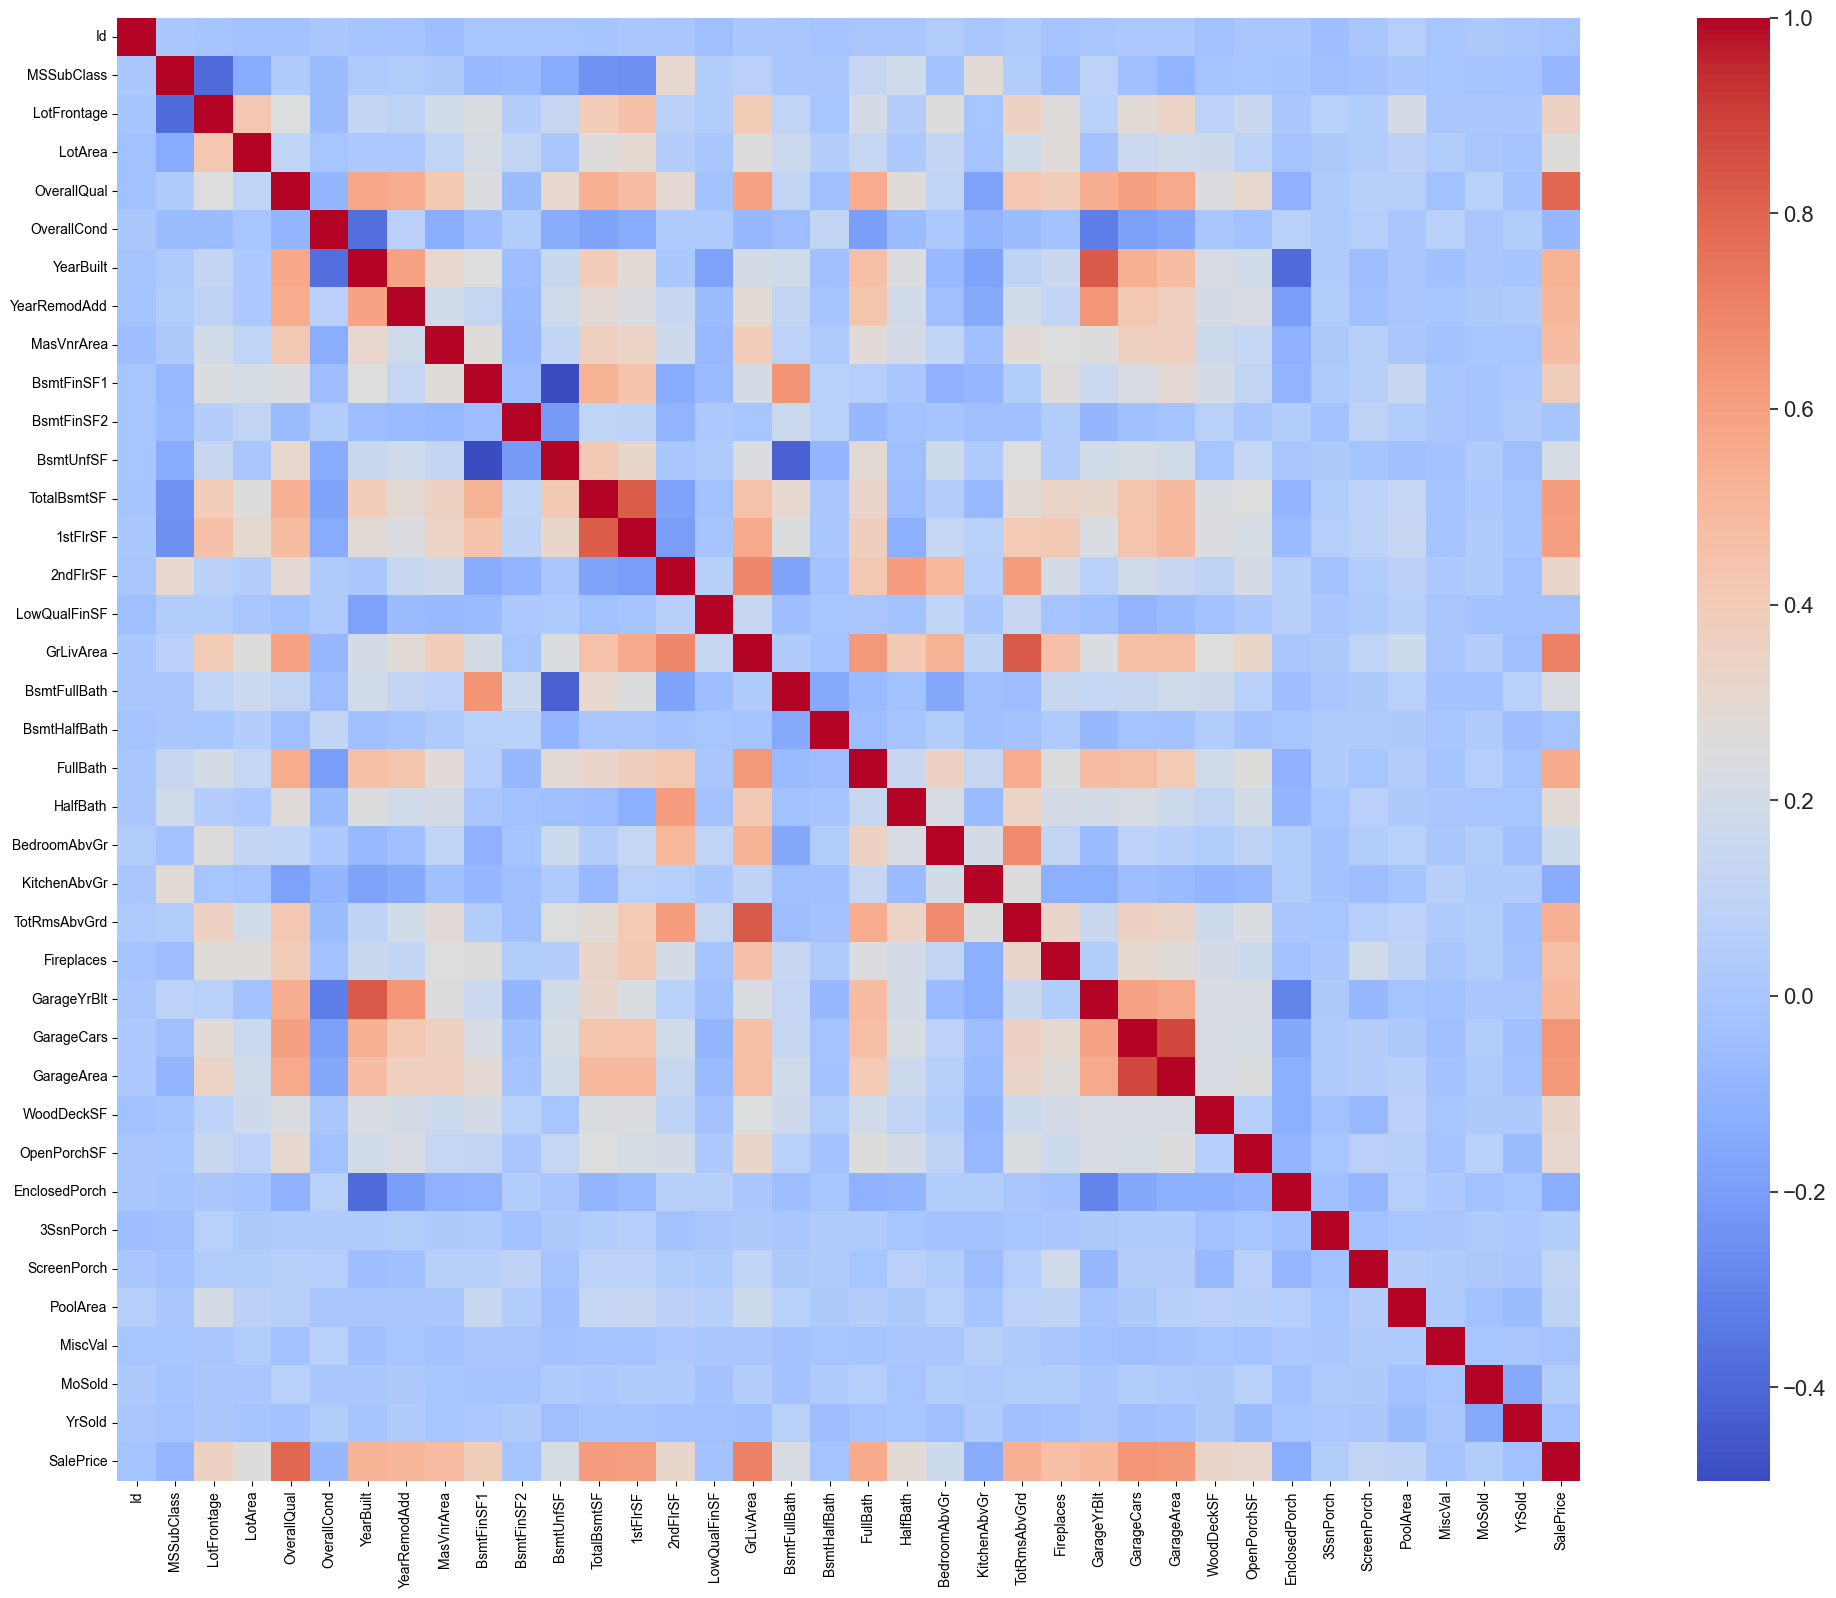

In [11]:
corrmat = train.corr(numeric_only=True)
f, ax = plt.subplots(figsize=(30, 19))
sns.set(font_scale=1.45)
sns.heatmap(corrmat, square=True, cmap='coolwarm')

In [12]:
correlations = corrmat["SalePrice"].sort_values(ascending=False)
features = correlations.index[0:10]
features

Index(['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea',
       'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt'],
      dtype='object')

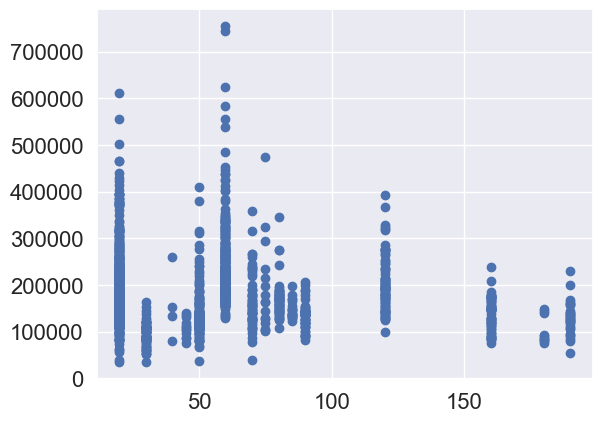

In [13]:
plt.scatter(x='MSSubClass', y='SalePrice', data=train)

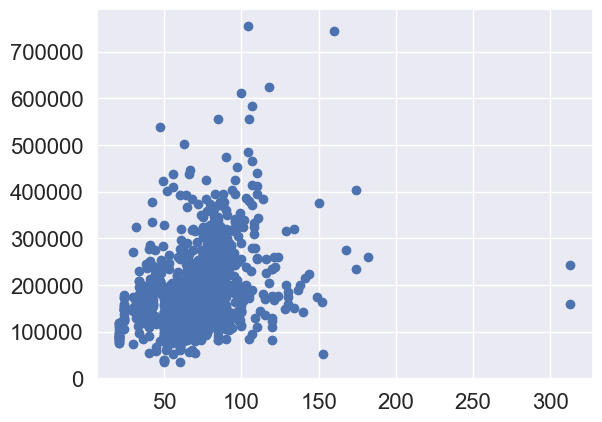

In [14]:
plt.scatter(x='LotFrontage', y='SalePrice', data=train)

In [15]:
train.query('LotFrontage > 300')
#Drop 935 and 1299

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
934,935,20,RL,313.0,27650,Pave,NaN,IR2,HLS,AllPub,...,0,NaN,NaN,NaN,0,11,2008,WD,Normal,242000
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


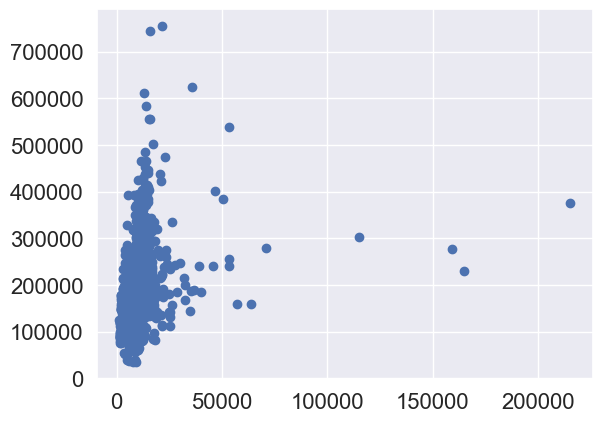

In [16]:
plt.scatter(x='LotArea', y='SalePrice', data=train)

In [17]:
train.query('LotArea > 55000')
#Drop 250, 314, 336, 707

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
249,250,50,RL,NaN,159000,Pave,NaN,IR2,Low,AllPub,...,0,NaN,NaN,Shed,500,6,2007,WD,Normal,277000
313,314,20,RL,150.0,215245,Pave,NaN,IR3,Low,AllPub,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,375000
335,336,190,RL,NaN,164660,Grvl,NaN,IR1,HLS,AllPub,...,0,NaN,NaN,Shed,700,8,2008,WD,Normal,228950
451,452,20,RL,62.0,70761,Pave,NaN,IR1,Low,AllPub,...,0,NaN,NaN,NaN,0,12,2006,WD,Normal,280000
706,707,20,RL,NaN,115149,Pave,NaN,IR2,Low,AllPub,...,0,NaN,NaN,NaN,0,6,2007,WD,Normal,302000
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000
1396,1397,20,RL,NaN,57200,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,160000


In [18]:
pd.Series(stats.zscore(train['LotArea'])).sort_values().tail(10)

384      4.268474
457      4.280500
769      4.308262
1396     4.678682
1298     5.348867
451      6.037793
706     10.486449
249     14.881285
335     15.448542
313     20.518273
dtype: float64

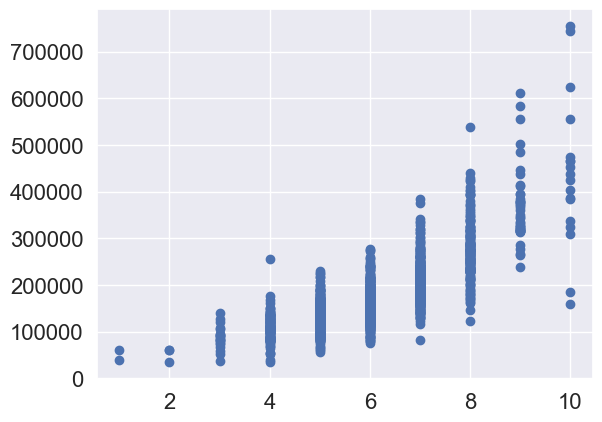

In [19]:
plt.scatter(x='OverallQual', y='SalePrice', data=train)

In [20]:
train.query('OverallQual == 10')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
58,59,60,RL,66.0,13682,Pave,NaN,IR2,HLS,AllPub,...,0,NaN,NaN,NaN,0,10,2006,New,Partial,438780
185,186,75,RM,90.0,22950,Pave,NaN,IR2,Lvl,AllPub,...,0,NaN,GdPrv,NaN,0,6,2006,WD,Normal,475000
224,225,20,RL,103.0,13472,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,386250
389,390,60,RL,96.0,12474,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2008,New,Partial,426000
440,441,20,RL,105.0,15431,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,555000
515,516,20,RL,94.0,12220,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2009,New,Partial,402861
523,524,60,RL,130.0,40094,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,NaN,0,10,2007,New,Partial,184750
583,584,75,RM,75.0,13500,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,325000
591,592,60,RL,97.0,13478,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2009,ConLI,Normal,451950
691,692,60,RL,104.0,21535,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2007,WD,Normal,755000


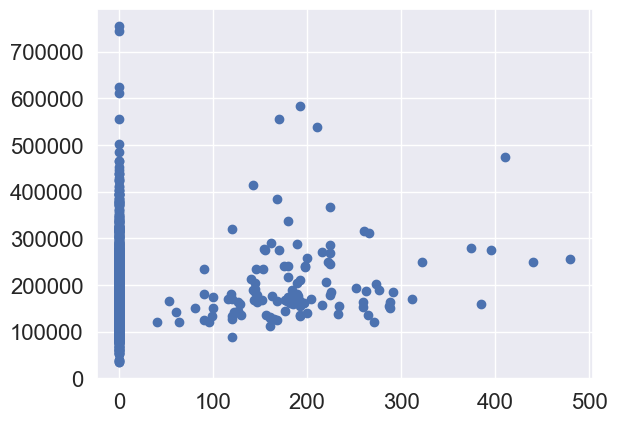

In [21]:
plt.scatter(x='ScreenPorch', y='SalePrice', data=train)

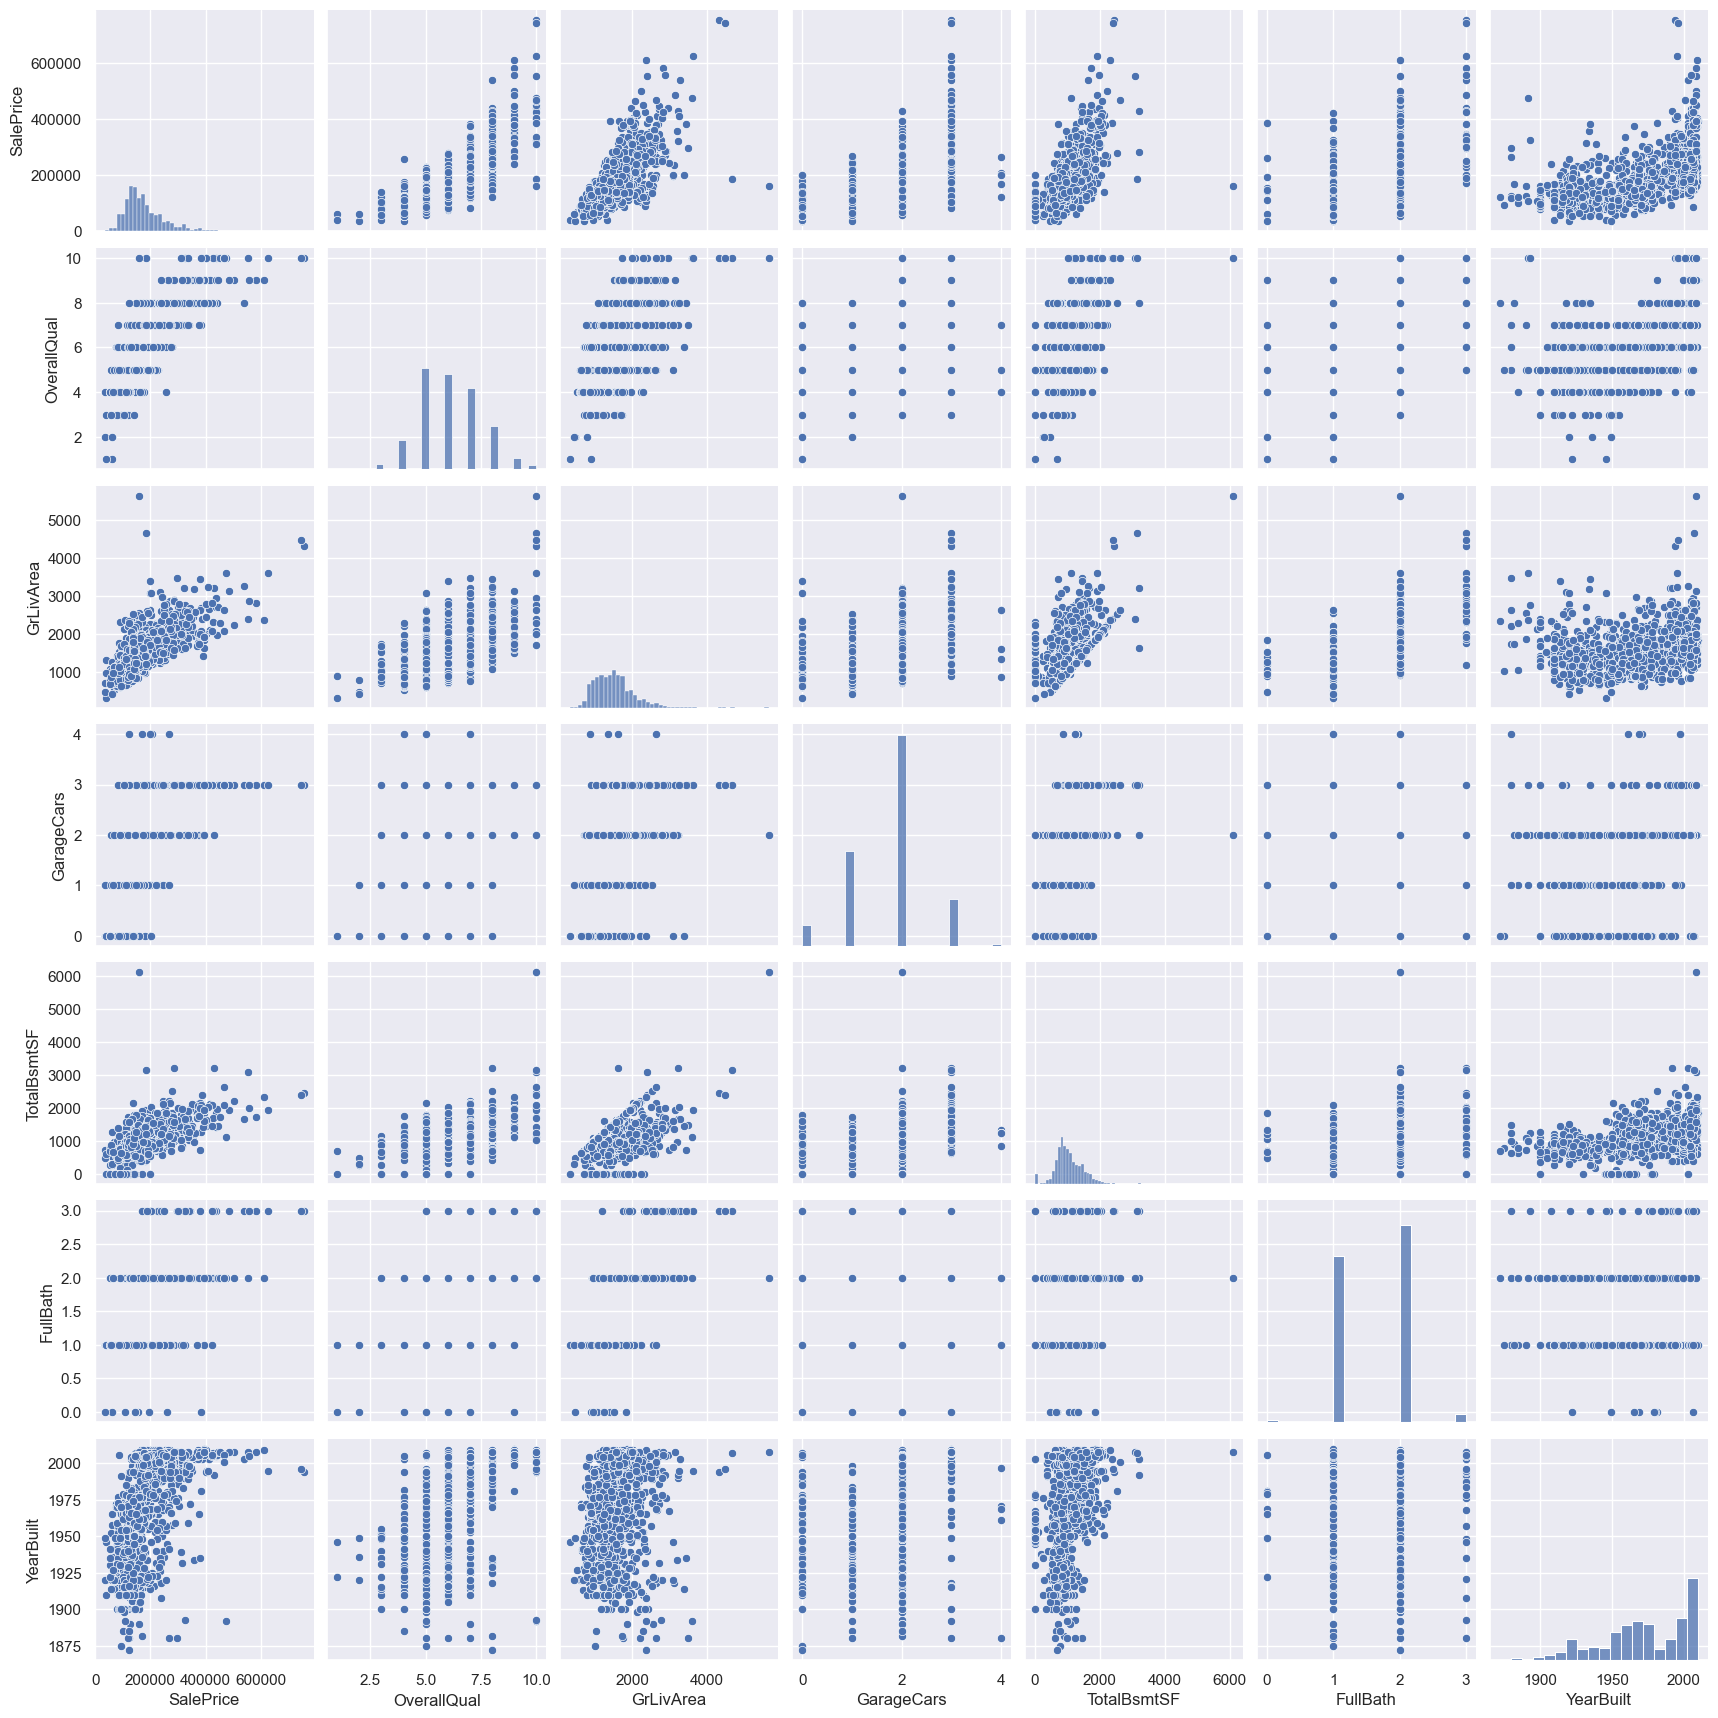

In [22]:
sns.set()
cols = ['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'FullBath', 'YearBuilt']
sns.pairplot(train[cols], size = 2.5)
plt.show()

<Axes: >

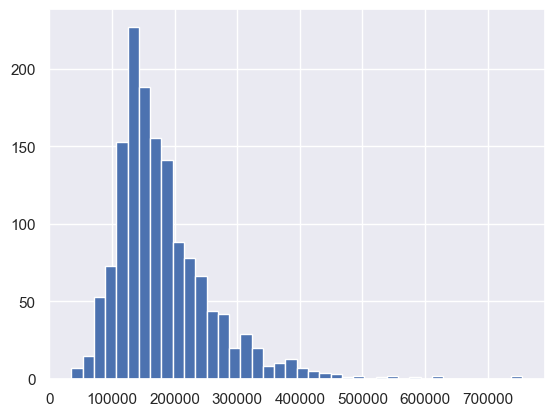

In [23]:
train['SalePrice'].hist(bins = 40)

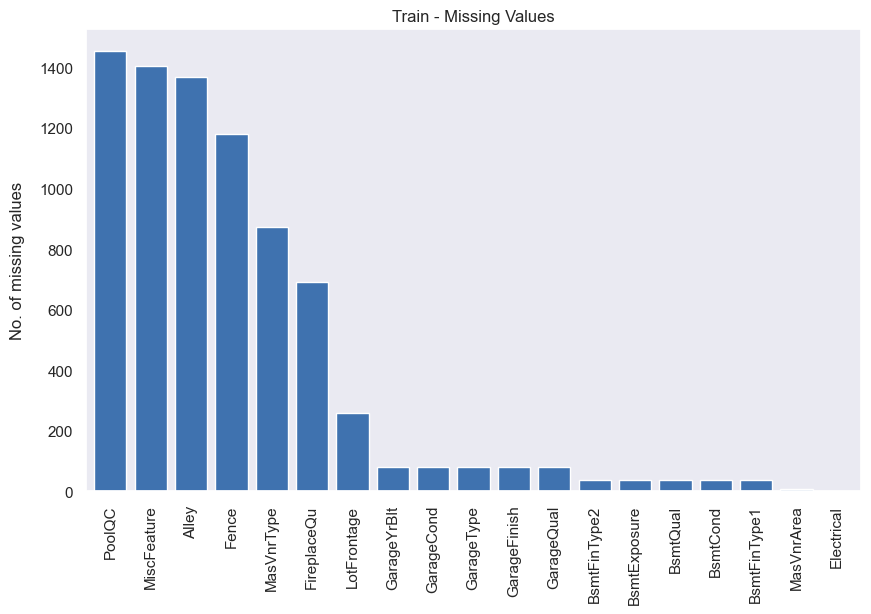

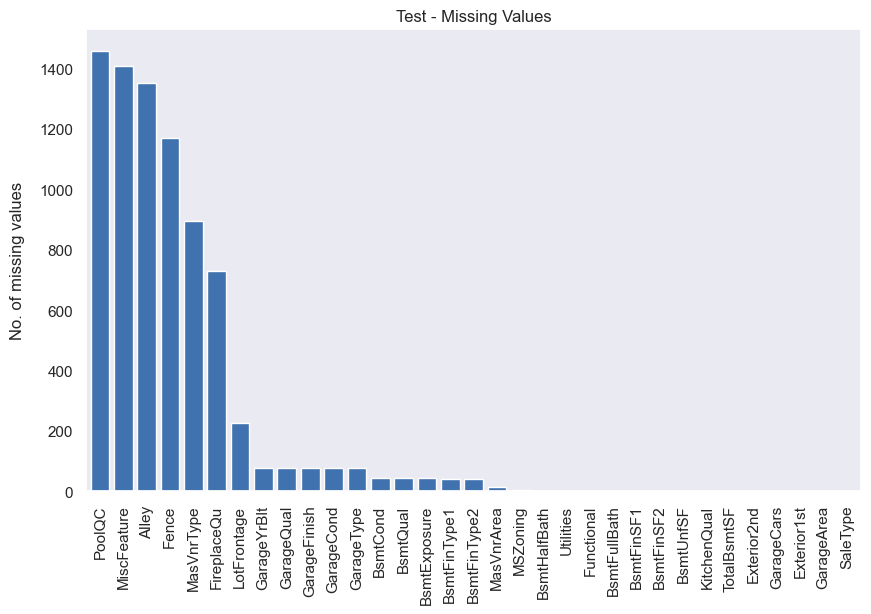

In [24]:
def plot_missing(df, title="Missing Values"):
    nans = df.isna().sum().sort_values(ascending=False)
    nans = nans[nans > 0]

    if len(nans) == 0:
        print("No missing values!")
        return

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.grid()
    ax.bar(nans.index, nans.values, zorder=2, color="#3f72af")
    ax.set_ylabel("No. of missing values", labelpad=10)
    ax.set_xlim(-0.6, len(nans) - 0.4)
    ax.xaxis.set_tick_params(rotation=90)
    plt.title(title)
    plt.show()

plot_missing(train, "Train - Missing Values")
plot_missing(test, "Test - Missing Values")


##### Discrete Values

In [25]:
numerical_features=[]
for feature in train:
    if train[feature].dtype!='O' and feature!= 'SalePrice':
        numerical_features.append(feature)

discrete_variables=[]
for feature in numerical_features:
    if len(train[feature].unique())<=25 and feature != 'SalePrice':
        discrete_variables.append(feature)

print(discrete_variables)

['MSSubClass', 'OverallQual', 'OverallCond', 'LowQualFinSF', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', '3SsnPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']


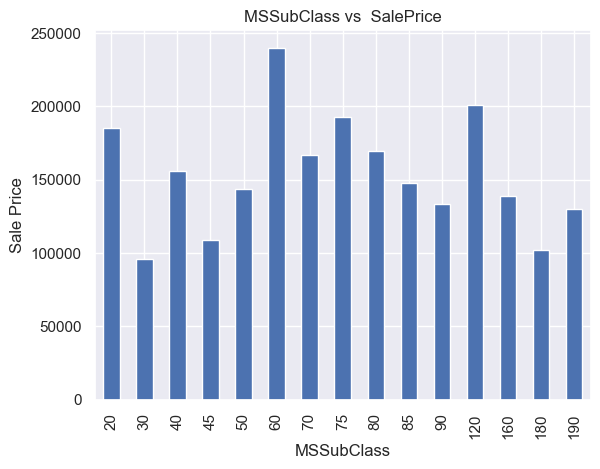

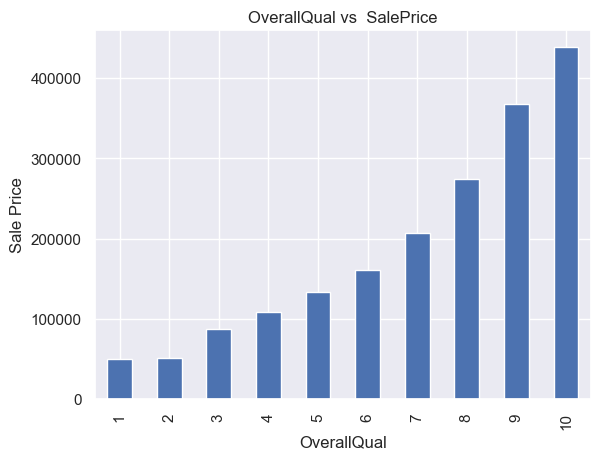

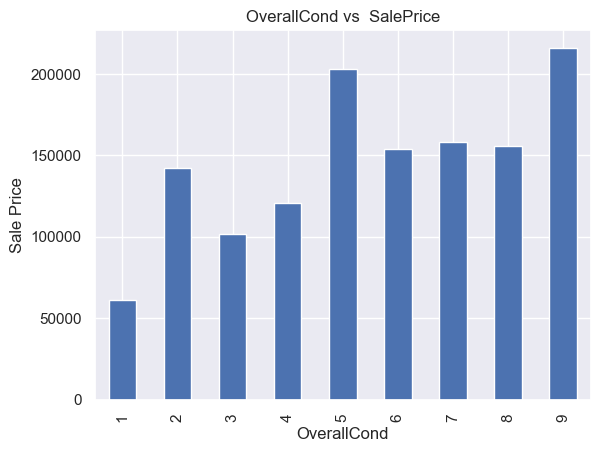

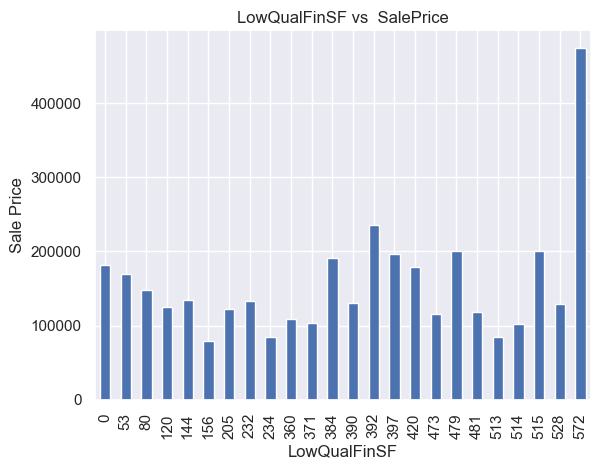

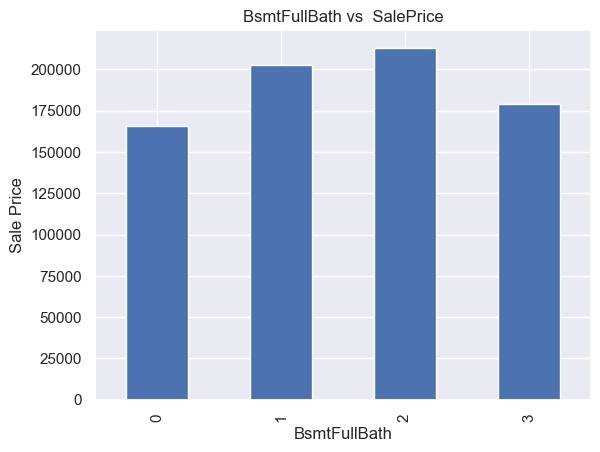

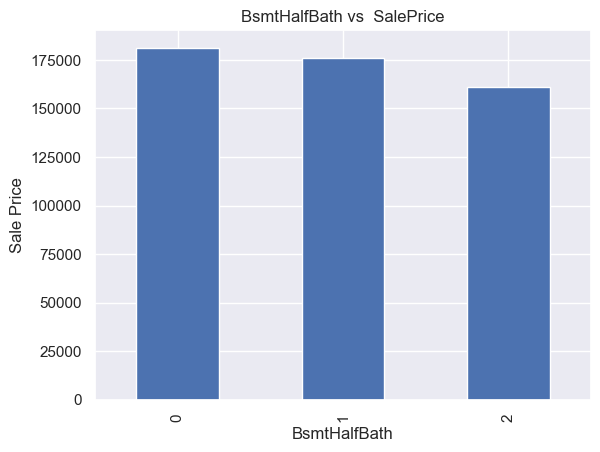

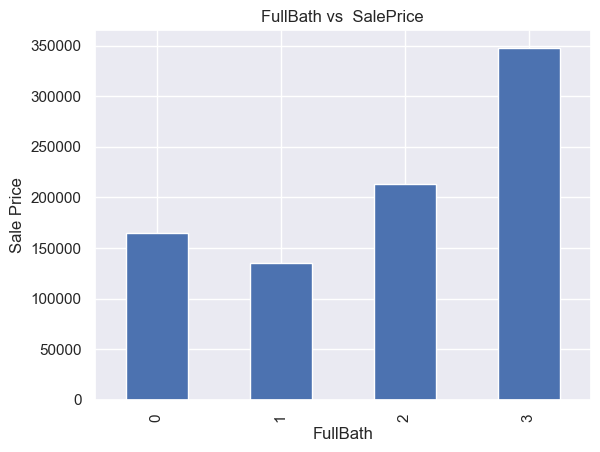

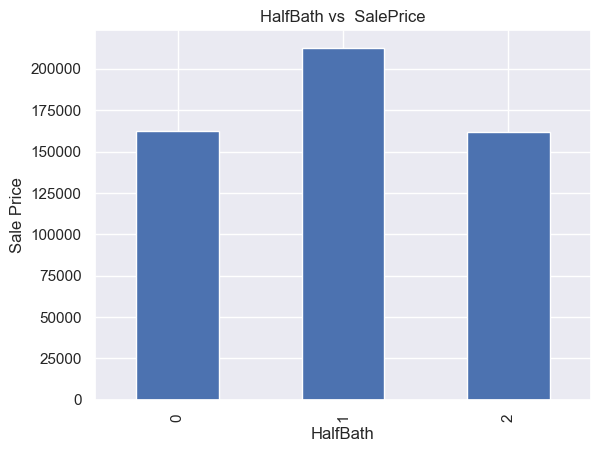

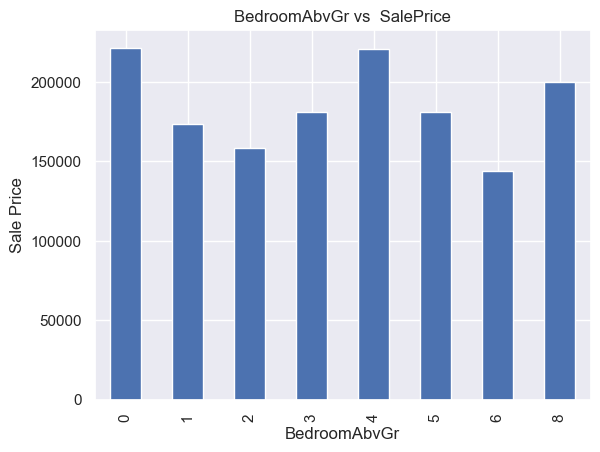

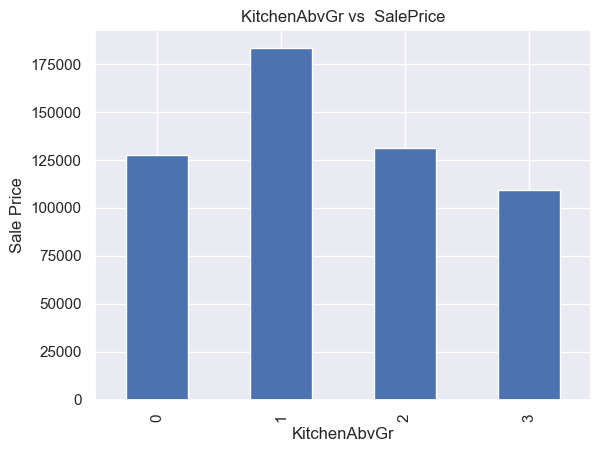

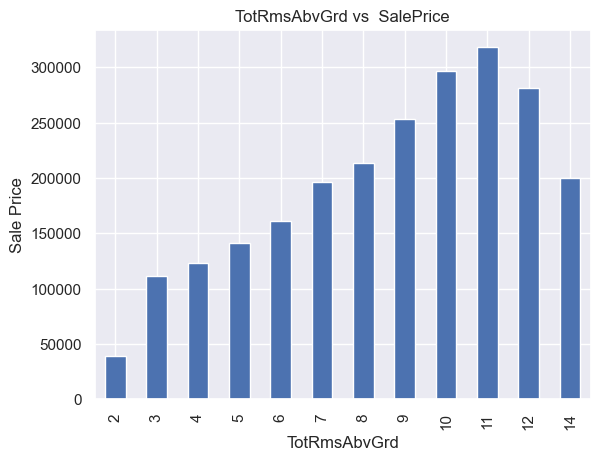

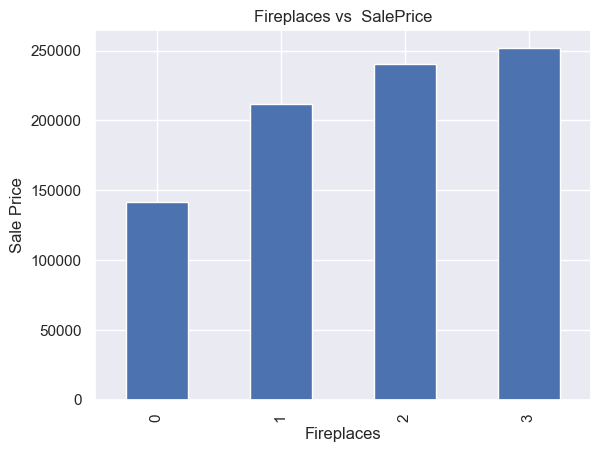

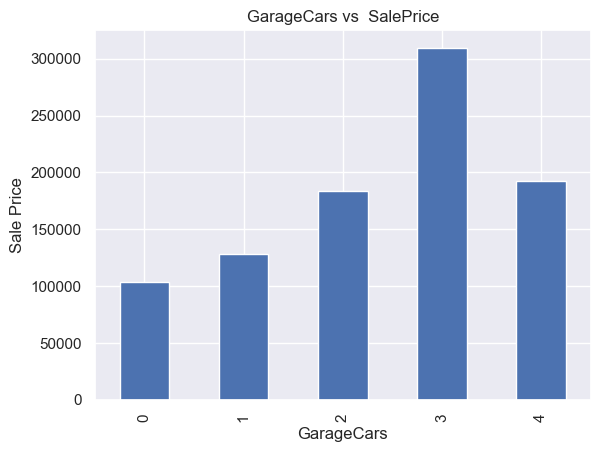

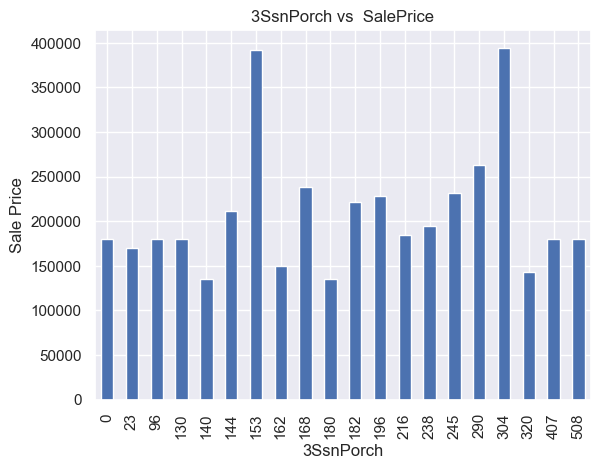

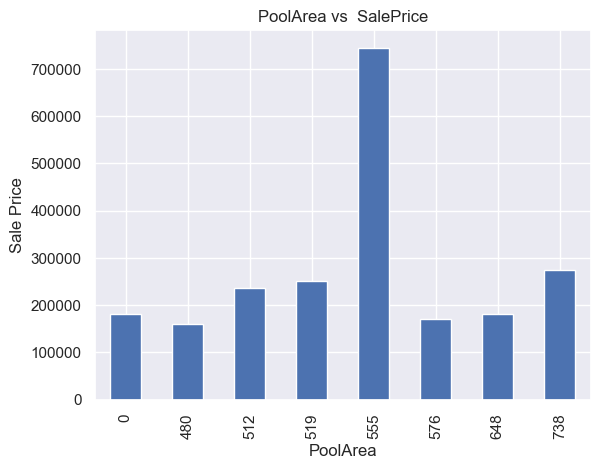

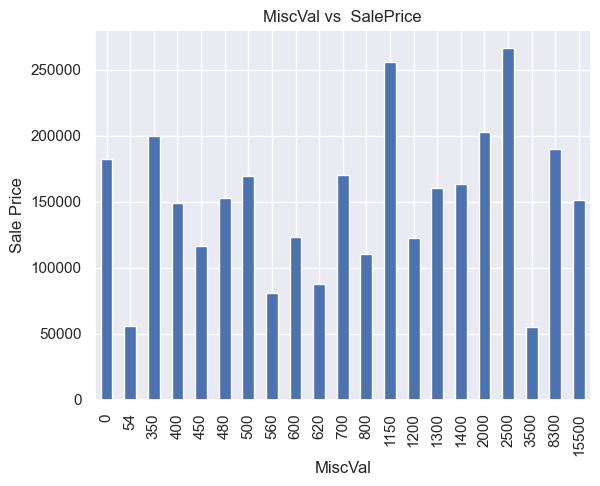

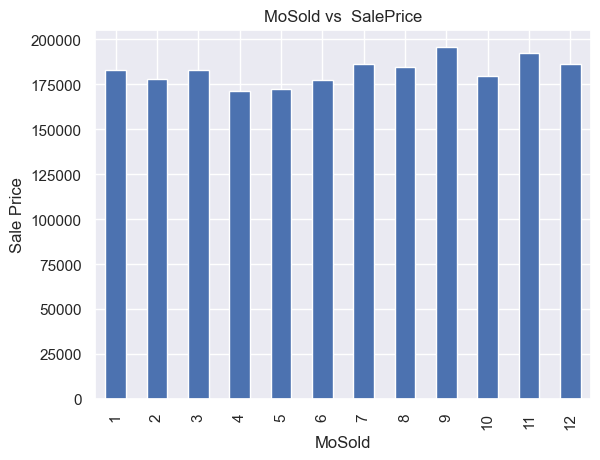

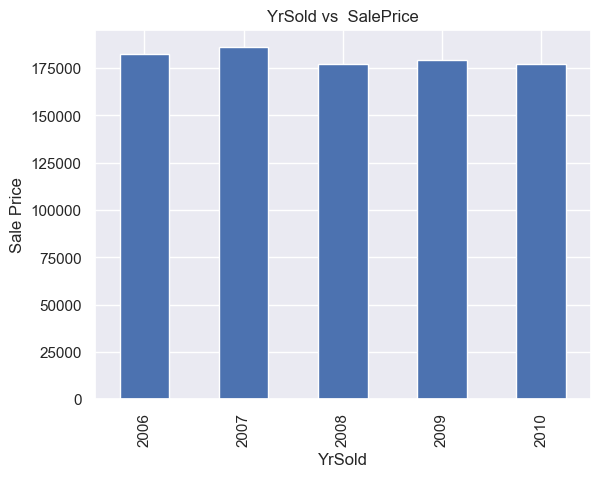

In [26]:
for feature in discrete_variables:
     train.groupby(feature)['SalePrice'].mean().plot.bar()
     plt.xlabel(feature)
     plt.ylabel('Sale Price')
     plt.title(feature +' vs '+' SalePrice')
     plt.show()

##### Continuous Values

In [27]:
continuous_variables=[]
for feature in numerical_features:
    if feature not in discrete_variables and feature not in ["YearBuilt","YearRemodAdd","GarageYrBlt","YrSold"]:
        continuous_variables.append(feature)

print(continuous_variables)

['Id', 'LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'GrLivArea', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', 'ScreenPorch']


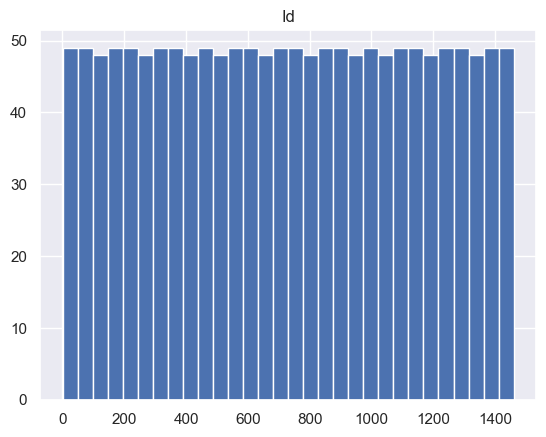

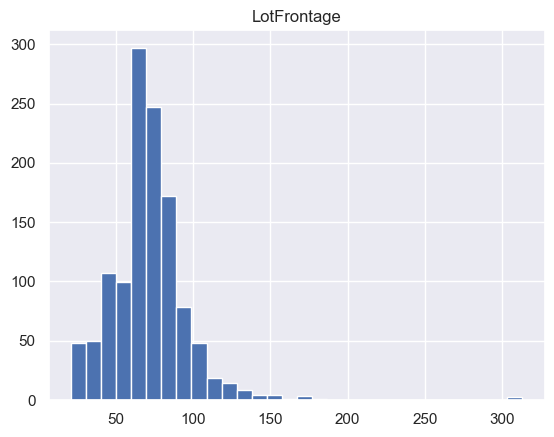

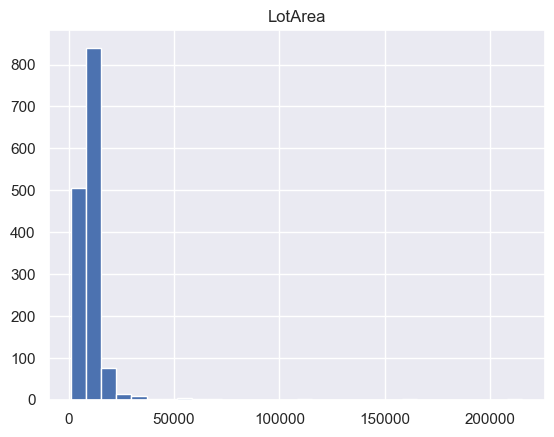

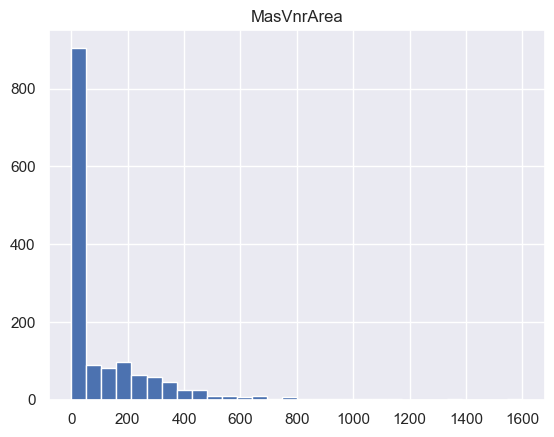

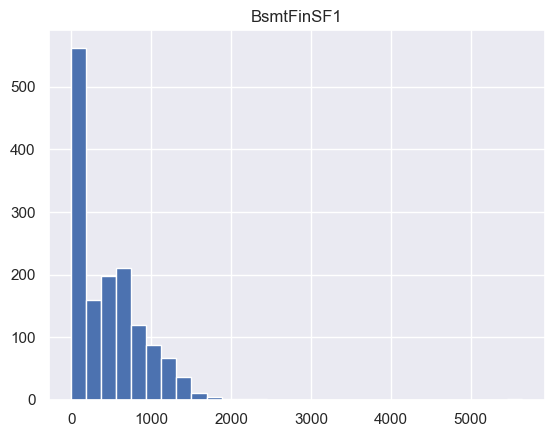

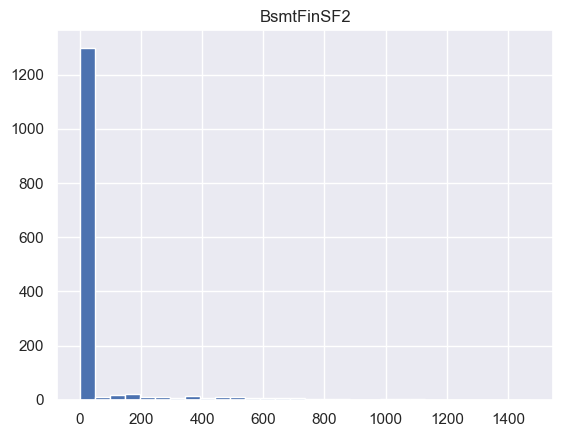

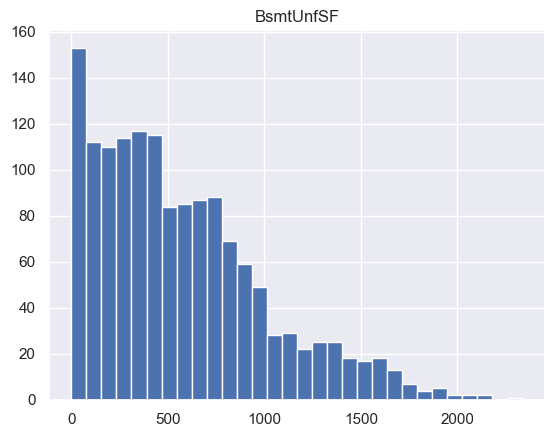

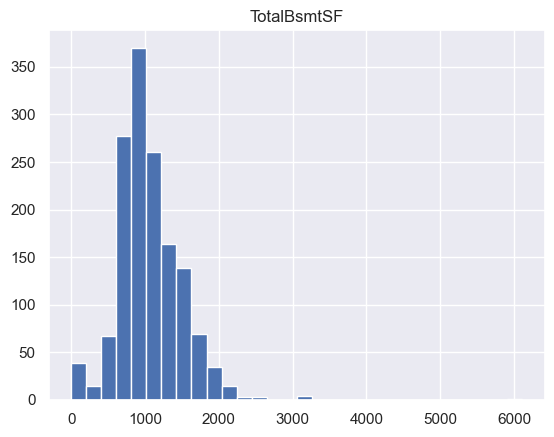

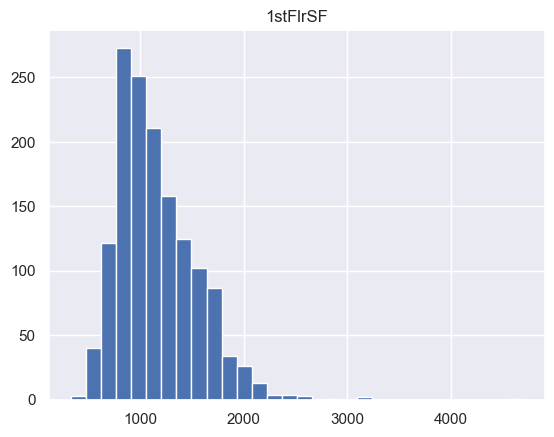

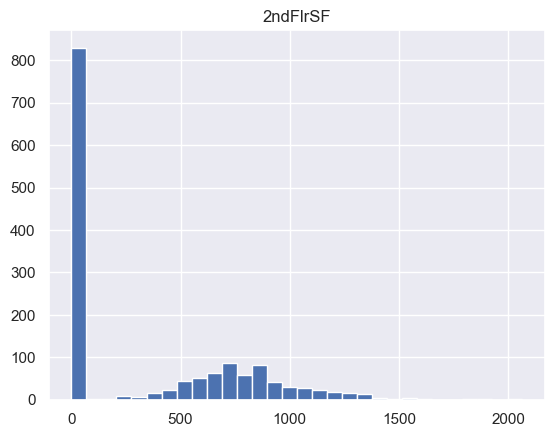

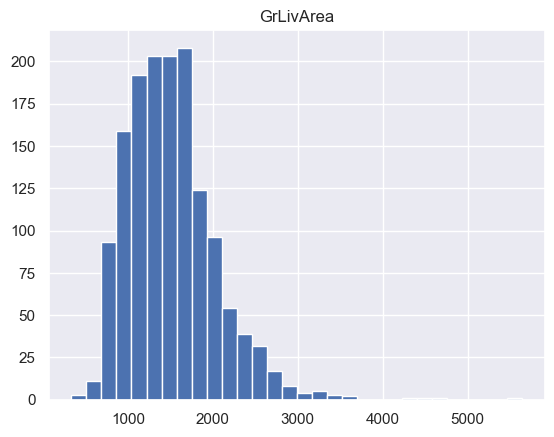

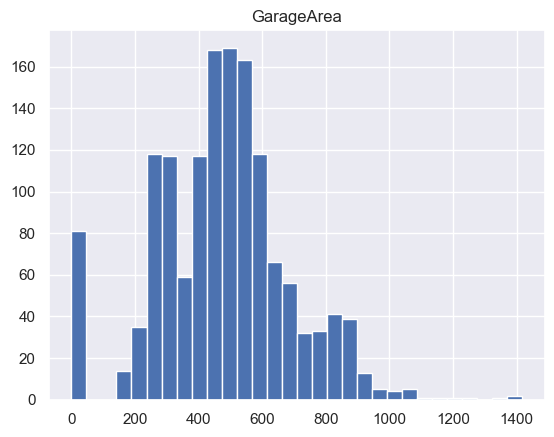

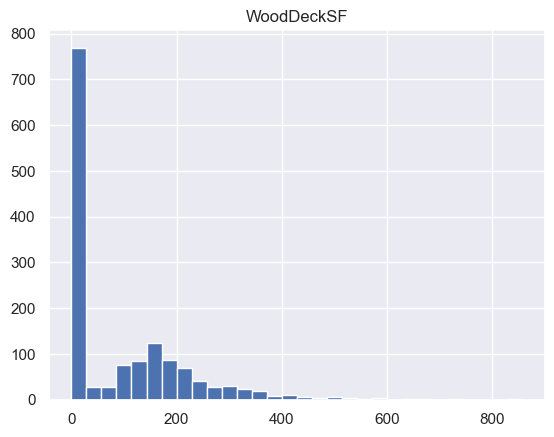

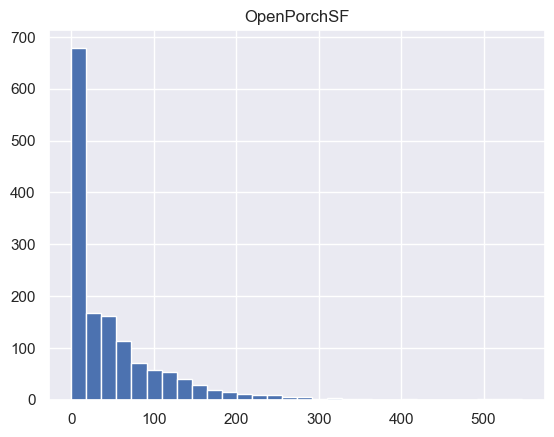

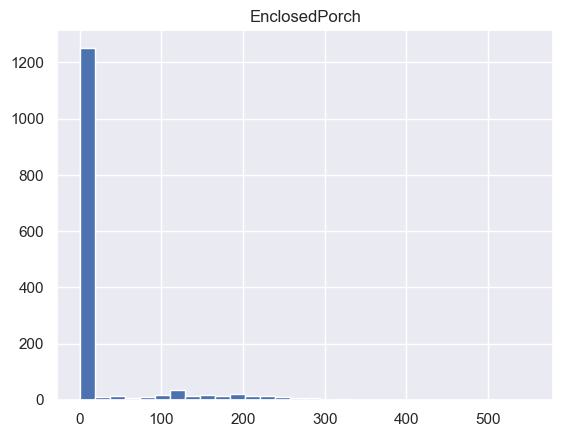

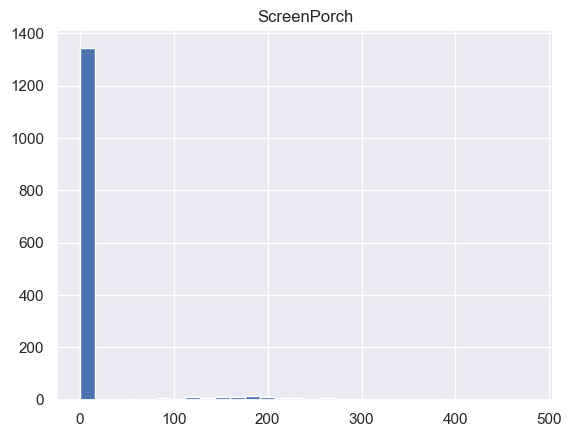

In [28]:
for feature in continuous_variables:
     train[feature].hist(bins=30)
     plt.title(feature)
     plt.show()

##### Catagorical Variables

In [29]:
categorical_features=[]
for feature in train.columns:
    if train[feature].dtype=='O'and feature!= 'SalePrice':
        categorical_features.append(feature)
print(categorical_features)

['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


<Axes: title={'center': 'Log Normal'}, xlabel='SalePrice'>

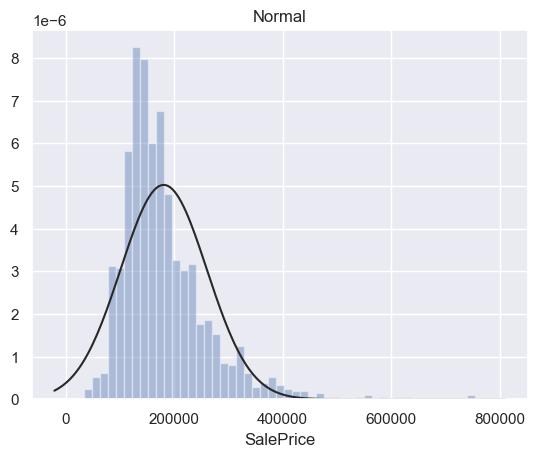

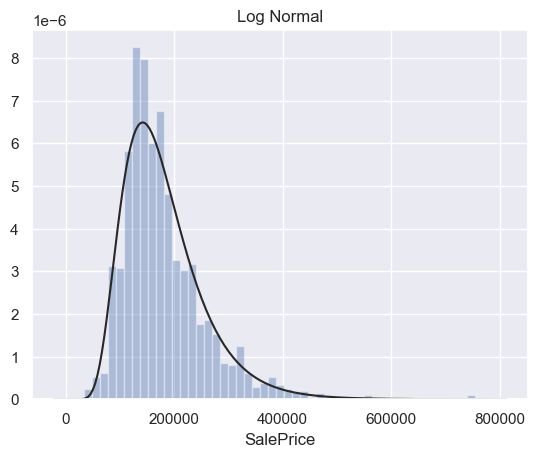

In [30]:
#Ploting the Distribution of the target variable
y1 = train['SalePrice']
plt.figure(2); plt.title('Normal')
sns.distplot(y1, kde=False, fit=stats.norm)
plt.figure(3); plt.title('Log Normal')
sns.distplot(y1, kde=False, fit=stats.lognorm)

In [31]:
train.drop(['Id'], axis=1, inplace=True)
test.drop(['Id'], axis=1, inplace=True)
data.drop(['Id'], axis=1, inplace=True)

In [32]:
training_null = pd.isnull(train).sum()
testing_null = pd.isnull(test).sum()

null = pd.concat([training_null, testing_null], axis=1, keys=["Training", "Testing"])

In [33]:
null_with_meaning = ["Alley", "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2", "FireplaceQu", "GarageType", "GarageFinish", "GarageQual", "GarageCond", "PoolQC", "Fence", "MiscFeature"]

In [34]:
for i in null_with_meaning:
    train[i].fillna("None", inplace=True)
    test[i].fillna("None", inplace=True)

In [35]:
features_modefill = ["MSZoning", "Utilities", "Exterior1st", "Exterior2nd",
                     "SaleType", "Electrical", "KitchenQual", "Functional", "MasVnrType"]

In [36]:
for col in features_modefill:
    train[col].fillna(train[col].mode()[0], inplace=True)
    test[col].fillna(test[col].mode()[0], inplace=True)

In [37]:
for col in ["LotFrontage", "GarageArea"]:
    train[col] = train.groupby("Neighborhood")[col].transform(lambda x: x.fillna(x.median()))
    test[col] = test.groupby("Neighborhood")[col].transform(lambda x: x.fillna(x.median()))

In [38]:
features_zerofill = ["GarageYrBlt", "MasVnrArea", "BsmtHalfBath", "BsmtFullBath",
                     "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF", "GarageCars"]

In [39]:
for col in features_zerofill:
    train[col].fillna(0, inplace=True)
    test[col].fillna(0, inplace=True)

### Feature Engineering

In [40]:
for df in [train, test]:
    df["TotalArea"] = df["GrLivArea"] + df["TotalBsmtSF"]
    df["TotalBaths"] = df["FullBath"] + df["BsmtFullBath"] + 0.5*(df["HalfBath"] + df["BsmtHalfBath"])
    df["TotalPorch"] = df["OpenPorchSF"] + df["EnclosedPorch"] + df["3SsnPorch"] + df["ScreenPorch"]
    df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
    df["RemodAge"] = df["YrSold"] - df["YearRemodAdd"]
    df["OverallScore"] = df["OverallQual"] * df["OverallCond"]

    df["LivArea_Qual"] = df["GrLivArea"] * df["OverallQual"]
    df["LivArea_Age"]  = df["GrLivArea"] / (df["HouseAge"] + 1)  
    df["Qual_TotalArea"] = df["OverallQual"] * df["TotalArea"]

In [41]:
for df in [train, test]:
    df['Pool'] = (df['PoolArea'] > 0).astype(int)
    df['2ndFloor'] = (df['2ndFlrSF'] > 0).astype(int)
    df['Garage'] = (df['GarageCars'] > 0).astype(int)
    df['Bsmt'] = (df['TotalBsmtSF'] > 0).astype(int)
    df['Fireplace'] = (df['Fireplaces'] > 0).astype(int)
    df['Porch'] = (df['TotalPorch'] > 0).astype(int)

In [42]:
for df in [train, test]:
    df["MoSoldsin"] = np.sin(2 * np.pi * df["MoSold"] / 12)
    df["MoSoldcos"] = np.cos(2 * np.pi * df["MoSold"] / 12)
    df.drop("MoSold", axis=1, inplace=True)

In [43]:
print("Train NaNs:", train.isnull().sum().max())  # should be 0
print("Test NaNs:", test.isnull().sum().max())    # should be 0

Train NaNs: 0
Test NaNs: 0


In [44]:
# --- Ordinal Encoding for quality/ranked features ---
quality_map = {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}
ordinal_cols = ["ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "HeatingQC",
                "KitchenQual", "FireplaceQu", "GarageQual", "GarageCond", "PoolQC"]

for col in ordinal_cols:
    for df in [train, test]:
        df[col] = df[col].map(quality_map).fillna(0).astype(int)

other_ordinal = {
    "BsmtExposure": {"None": 0, "No": 1, "Mn": 2, "Av": 3, "Gd": 4},
    "BsmtFinType1": {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6},
    "BsmtFinType2": {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6},
    "GarageFinish": {"None": 0, "Unf": 1, "RFn": 2, "Fin": 3},
    "Fence": {"None": 0, "MnWw": 1, "GdWo": 2, "MnPrv": 3, "GdPrv": 4},
    "Functional": {"Sal": 1, "Sev": 2, "Maj2": 3, "Maj1": 4, "Mod": 5, "Min2": 6, "Min1": 7, "Typ": 8},
    "LandSlope": {"Sev": 1, "Mod": 2, "Gtl": 3},
    "LotShape": {"IR3": 1, "IR2": 2, "IR1": 3, "Reg": 4},
    "PavedDrive": {"N": 0, "P": 1, "Y": 2},
    "Street": {"Grvl": 0, "Pave": 1},
    "CentralAir": {"N": 0, "Y": 1},
    "Utilities": {"ELO": 1, "NoSeWa": 2, "NoSewr": 3, "AllPub": 4},
}

for col, mapping in other_ordinal.items():
    for df in [train, test]:
        if col in df.columns:
            df[col] = df[col].map(mapping).fillna(0).astype(int)

encoded_ordinal = ordinal_cols + list(other_ordinal.keys())
print(f"Ordinal encoded: {len(encoded_ordinal)} columns")

# --- One-Hot Encoding for nominal features ---
nominal_cols = [c for c in train.select_dtypes(include="object").columns]
print(f"One-Hot encoding: {len(nominal_cols)} nominal columns: {nominal_cols}")

train = pd.get_dummies(train, columns=nominal_cols, drop_first=True)
test = pd.get_dummies(test, columns=nominal_cols, drop_first=True)

train, test = train.align(test, join="left", axis=1, fill_value=0)
if "SalePrice" not in train.columns:
    train["SalePrice"] = pd.read_csv("house-prices-advanced-regression-techniques/train.csv")["SalePrice"]
test.drop(columns=["SalePrice"], inplace=True, errors="ignore")

print(f"Final train shape: {train.shape}")
print(f"Final test shape: {test.shape}")

Ordinal encoded: 22 columns
One-Hot encoding: 21 nominal columns: ['MSZoning', 'Alley', 'LandContour', 'LotConfig', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'Heating', 'Electrical', 'GarageType', 'MiscFeature', 'SaleType', 'SaleCondition']
Final train shape: (1460, 218)
Final test shape: (1459, 217)


In [45]:
train_clean = train.copy()
print(f"Original: {len(train_clean)} rows")

mask_grliv = ~((train_clean["GrLivArea"] > 4000) & (train_clean["SalePrice"] < 300000))
train_clean = train_clean[mask_grliv]

mask_lot = train_clean["LotArea"] < 100000
train_clean = train_clean[mask_lot]

mask_price = train_clean["SalePrice"] < 700000
train_clean = train_clean[mask_price]

print(f"After targeted removal: {len(train_clean)} rows")
print(f"Removed: {len(train) - len(train_clean)} rows ({(len(train) - len(train_clean)) / len(train) * 100:.1f}%)")

Original: 1460 rows
After targeted removal: 1452 rows
Removed: 8 rows (0.5%)


In [46]:
from scipy.stats import skew

numeric_feats = train_clean.drop(columns=["SalePrice"]).select_dtypes(include=[np.number]).columns
skewed_feats = train_clean[numeric_feats].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
high_skew = skewed_feats[abs(skewed_feats) > 0.75]
print(f"Correcting skew for {len(high_skew)} features")

for col in high_skew.index:
    train_clean.loc[:, col] = np.log1p(train_clean[col].clip(lower=0))
    test.loc[:, col] = np.log1p(test[col].clip(lower=0))

print("Skew correction applied")

Correcting skew for 47 features
Skew correction applied


Feature Selection

In [47]:
X = train_clean.drop(columns=['SalePrice'])
y = np.log1p(train_clean['SalePrice'])

In [48]:
selector = SelectKBest(f_regression, k=30)
selector.fit(X, y)

,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function f_r...t 0x134b66de0>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",30


In [49]:
feature_scores = pd.DataFrame({
    'feature': X.columns,
    'score': selector.scores_
}).sort_values('score', ascending=False)

print("Top 30 features:")
print(feature_scores.head(30))

Top 30 features:
               feature        score
65      Qual_TotalArea  5006.996219
63        LivArea_Qual  3714.054372
7          OverallQual  2998.995467
57           TotalArea  2893.888672
28           GrLivArea  1675.641755
64         LivArea_Age  1606.307049
12           ExterQual  1272.763113
42          GarageCars  1256.330713
58          TotalBaths  1192.412993
35         KitchenQual  1179.883174
43          GarageArea  1096.695838
22         TotalBsmtSF  1002.062942
25            1stFlrSF   853.944490
41        GarageFinish   841.809980
62        OverallScore   839.152712
60            HouseAge   783.353343
9            YearBuilt   780.831384
31            FullBath   774.713371
61            RemodAge   712.434338
10        YearRemodAdd   703.431484
39         FireplaceQu   613.556228
181   Foundation_PConc   586.676154
36        TotRmsAbvGrd   580.342669
70           Fireplace   507.392309
14            BsmtQual   479.510272
38          Fireplaces   441.851979
23         

In [50]:
selected_features = feature_scores.head(30)['feature'].tolist()
print(f"\nSelected {len(selected_features)} features out of {X.shape[1]}")


Selected 30 features out of 217


### Feature Selection - SelectFromModel (Random Forest)
SelectFromModel ახდენს feature-ების შეფასებას Random Forest-ის feature importance-ით.
ეს ითვალისწინებს არაწრფივ კავშირებს, რაც XGBoost-ისთვის უკეთესი შერჩევაა ვიდრე f_regression.

In [51]:
from sklearn.feature_selection import SelectFromModel

X_all = train_clean.drop(columns=["SalePrice"])
y_all = np.log1p(train_clean["SalePrice"])

rf_selector = RandomForestRegressor(n_estimators=200, random_state=42, max_depth=10, n_jobs=-1)
rf_selector.fit(X_all, y_all)

sfm = SelectFromModel(rf_selector, threshold="median")
sfm.fit(X_all, y_all)
rf_selected_features = X_all.columns[sfm.get_support()].tolist()

importances = pd.Series(rf_selector.feature_importances_, index=X_all.columns).sort_values(ascending=False)
print(f"SelectFromModel (RF) selected {len(rf_selected_features)} features")
print(f"\nTop 20 features by RF importance:")
print(importances.head(20))

SelectFromModel (RF) selected 109 features

Top 20 features by RF importance:
Qual_TotalArea    0.782862
LivArea_Age       0.028687
LivArea_Qual      0.020720
CentralAir        0.009189
LotArea           0.008547
BsmtUnfSF         0.007943
OverallScore      0.007233
RemodAge          0.007095
BsmtFinSF1        0.006986
GarageArea        0.006817
TotalArea         0.005270
1stFlrSF          0.004941
GarageYrBlt       0.004639
YearRemodAdd      0.004598
TotalBaths        0.004334
MSZoning_RM       0.004300
OverallCond       0.004063
GrLivArea         0.003836
LotFrontage       0.003600
HouseAge          0.003428
dtype: float64


In [62]:
with mlflow.start_run(run_name="linear_regression_baseline"):
    X = train_clean.drop(columns=['SalePrice'])
    y = np.log1p(train_clean['SalePrice'])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    train_pred = model.predict(X_train)
    test_pred  = model.predict(X_test)
    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse  = np.sqrt(mean_squared_error(np.expm1(y_test),  np.expm1(test_pred)))
    r2         = r2_score(y_test, test_pred)
    
    mlflow.log_param("model_type", "LinearRegression")
    mlflow.log_param("feature_selection", "none")
    mlflow.log_param("n_features", X.shape[1])
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("r2", r2)
    mlflow.sklearn.log_model(model, "model")
    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f} | R2: {r2:.4f}")

2026/04/12 12:50:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/12 12:50:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Train RMSE: 16,481
Test RMSE:  21,052 | R2: 0.9119
🏃 View run linear_regression_baseline at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/26cd63b44f664c13bba137efcd9a6a36
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


In [50]:
with mlflow.start_run(run_name="linear_regression_selectkbest_k30"):
    X_selected = train_clean[selected_features]
    y = np.log1p(train_clean['SalePrice'])

    X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

    model = LinearRegression()
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(test_pred)))
    r2 = r2_score(y_test, test_pred)

    mlflow.log_param("model_type", "LinearRegression")
    mlflow.log_param("feature_selection", "SelectKBest")
    mlflow.log_param("k_features", 30)
    mlflow.log_param("log_transform", True)
    mlflow.log_param("outlier_removal", "zscore_3")
    mlflow.log_param("feature_engineering", True)
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("r2", r2)
    mlflow.sklearn.log_model(model, "model")

    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f} | R2: {r2:.4f}")

2026/04/11 12:13:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/11 12:14:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Train RMSE: 20,498
Test RMSE:  19,784 | R2: 0.8861
🏃 View run linear_regression_selectkbest_k30 at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/e7b1a2d25378452eb037063442db51f4
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


In [100]:
with mlflow.start_run(run_name="linear_regression_underfit"):
    underfit_features = ['GrLivArea', 'OverallQual', 'YearBuilt']

    X = train_clean[underfit_features]
    y = np.log1p(train_clean['SalePrice'])

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = LinearRegression()
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(test_pred)))
    r2 = r2_score(y_test, test_pred)

    mlflow.log_param("model_type", "LinearRegression_underfit")
    mlflow.log_param("features_used", 3)
    mlflow.log_param("feature_list", "GrLivArea, OverallQual, YearBuilt")
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("r2", r2)
    mlflow.sklearn.log_model(model, "model")

    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f}")
    print(f"R2: {r2:.4f}")

2026/04/11 00:29:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/11 00:29:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Train RMSE: 28,955
Test RMSE:  28,020
R2: 0.8271
🏃 View run linear_regression_underfit at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/e2ba51afd3ea4c618be930a04f021a59
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


Ridge

In [53]:
with mlflow.start_run(run_name="ridge_overfit_attempt"):
    X = train_clean.drop(columns=['SalePrice'])
    y = np.log1p(train_clean['SalePrice'])

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = Ridge(alpha=0.0001)  
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(test_pred)))
    r2 = r2_score(y_test, test_pred)

    mlflow.log_param("model_type", "Ridge")
    mlflow.log_param("alpha", 0.0001)
    mlflow.log_param("log_transform", True)
    mlflow.log_param("outlier_removal", "zscore_3")
    mlflow.log_param("feature_engineering", True)
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("r2", r2)
    mlflow.sklearn.log_model(model, "model")

    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f}")
    print(f"R2: {r2:.4f}")

2026/04/12 12:40:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/12 12:40:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Train RMSE: 16,484
Test RMSE:  21,075
R2: 0.9118
🏃 View run ridge_overfit_attempt at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/cabbd04dea9c452cbcd6bc2de041c93c
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


In [49]:
from sklearn.model_selection import GridSearchCV

with mlflow.start_run(run_name="ridge_baseline2"):
    X = train_clean.drop(columns=['SalePrice'])
    y = np.log1p(train_clean['SalePrice'])

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    param_grid = {'alpha': [0.01, 0.1, 1, 10, 50, 100, 200]}
    model = GridSearchCV(Ridge(), param_grid, cv=5, scoring='neg_root_mean_squared_error')
    model.fit(X_train, y_train)

    best_alpha = model.best_params_['alpha']

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(test_pred)))
    r2 = r2_score(y_test, test_pred)

    mlflow.log_param("model_type", "Ridge")
    mlflow.log_param("best_alpha", best_alpha)
    mlflow.log_param("log_transform", True)
    mlflow.log_param("outlier_removal", "zscore_3")
    mlflow.log_param("feature_engineering", True)
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("r2", r2)
    mlflow.sklearn.log_model(model, "model")

    print(f"Best alpha: {best_alpha}")
    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f} | R2: {r2:.4f}")

2026/04/11 01:29:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/11 01:29:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Best alpha: 50
Train RMSE: 18,176
Test RMSE:  17,208 | R2: 0.9188
🏃 View run ridge_baseline2 at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/ce0c93b8010a4d14b9c708bb0b4a68fa
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


In [64]:
with mlflow.start_run(run_name="ridge_selectkbest_k30"):
    X_selected = train_clean[selected_features]
    y = np.log1p(train_clean['SalePrice'])
    X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)
    model = Ridge(alpha=1.0)
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(test_pred)))
    r2 = r2_score(y_test, test_pred)
    mlflow.log_param("model_type", "Ridge")
    mlflow.log_param("feature_selection", "SelectKBest")
    mlflow.log_param("k_features", 30)
    mlflow.log_param("alpha", 1.0)
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("r2", r2)
    mlflow.sklearn.log_model(model, "model")
    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f} | R2: {r2:.4f}")

2026/04/12 13:19:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/12 13:20:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Train RMSE: 24,194
Test RMSE:  24,404 | R2: 0.8892
🏃 View run ridge_selectkbest_k30 at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/fa5ea63856704745a619a7244d7fa807
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


Lasso

In [47]:
with mlflow.start_run(run_name="lasso_underfit"):
    X = train_clean.drop(columns=['SalePrice'])
    y = np.log1p(train_clean['SalePrice'])

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = Lasso(alpha=10)  
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(test_pred)))
    r2 = r2_score(y_test, test_pred)

    mlflow.log_param("model_type", "Lasso")
    mlflow.log_param("alpha", 10)
    mlflow.log_param("log_transform", True)
    mlflow.log_param("outlier_removal", "zscore_3")
    mlflow.log_param("feature_engineering", True)
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("r2", r2)
    mlflow.sklearn.log_model(model, "model")

    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f}")
    print(f"R2: {r2:.4f}")

2026/04/11 11:31:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/11 11:31:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Train RMSE: 33,404
Test RMSE:  34,843
R2: 0.7176
🏃 View run lasso_underfit at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/61c2fa0194614459a806a0fe7b1a3653
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


In [54]:
from sklearn.model_selection import GridSearchCV
with mlflow.start_run(run_name="lasso_baseline"):
    X = train_clean.drop(columns=['SalePrice'])
    y = np.log1p(train_clean['SalePrice'])

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    param_grid = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1]}
    model = GridSearchCV(Lasso(), param_grid, cv=5, scoring='neg_root_mean_squared_error')
    model.fit(X_train, y_train)

    best_alpha = model.best_params_['alpha']

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(test_pred)))
    r2 = r2_score(y_test, test_pred)

    mlflow.log_param("model_type", "Lasso")
    mlflow.log_param("best_alpha", best_alpha)
    mlflow.log_param("log_transform", True)
    mlflow.log_param("outlier_removal", "zscore_3")
    mlflow.log_param("feature_engineering", True)
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("r2", r2)
    mlflow.sklearn.log_model(model, "model")

    print(f"Best alpha: {best_alpha}")
    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f} | R2: {r2:.4f}")

2026/04/11 22:30:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/11 22:30:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Best alpha: 0.001
Train RMSE: 18,240
Test RMSE:  17,207 | R2: 0.9220
🏃 View run lasso_baseline at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/8c4b03ed9ef7432698a3e2fe6684c0f9
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


**Descision Trees**

In [57]:
with mlflow.start_run(run_name="decision_tree_overfit"):
    X = train_clean.drop(columns=['SalePrice'])
    y = np.log1p(train_clean['SalePrice'])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = DecisionTreeRegressor(max_depth=None) 
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(test_pred)))
    r2 = r2_score(y_test, test_pred)
    mlflow.log_param("model_type", "DecisionTree")
    mlflow.log_param("max_depth", "None")
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("r2", r2)
    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f} | R2: {r2:.4f}")

Train RMSE: 0
Test RMSE:  34,557 | R2: 0.6888
🏃 View run decision_tree_overfit at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/db7396b076d04690afafc38ddfd17925
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


In [58]:
with mlflow.start_run(run_name="decision_tree_underfit"):
    X = train_clean.drop(columns=['SalePrice'])
    y = np.log1p(train_clean['SalePrice'])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = DecisionTreeRegressor(max_depth=2) 
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(test_pred)))
    r2 = r2_score(y_test, test_pred)
    mlflow.log_param("model_type", "DecisionTree")
    mlflow.log_param("max_depth", 2)
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("r2", r2)
    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f} | R2: {r2:.4f}")

Train RMSE: 38,587
Test RMSE:  39,315 | R2: 0.6125
🏃 View run decision_tree_underfit at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/c6c146c2e98b4ffd834745ce9e08453a
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


In [59]:
with mlflow.start_run(run_name="decision_tree_tuned"):
    X = train_clean.drop(columns=['SalePrice'])
    y = np.log1p(train_clean['SalePrice'])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = DecisionTreeRegressor(max_depth=5)
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(test_pred)))
    r2 = r2_score(y_test, test_pred)
    mlflow.log_param("model_type", "DecisionTree")
    mlflow.log_param("max_depth", 5)
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("r2", r2)
    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f} | R2: {r2:.4f}")

Train RMSE: 22,412
Test RMSE:  26,831 | R2: 0.7911
🏃 View run decision_tree_tuned at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/7b7bb3daf56e44839828e95975a8495c
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


Random Forest

In [60]:
with mlflow.start_run(run_name="random_forest_overfit"):
    X = train_clean.drop(columns=['SalePrice'])
    y = np.log1p(train_clean['SalePrice'])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = RandomForestRegressor(n_estimators=100, max_depth=None, random_state=42)
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(test_pred)))
    r2 = r2_score(y_test, test_pred)
    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", "None")
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("r2", r2)
    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f} | R2: {r2:.4f}")

Train RMSE: 9,341
Test RMSE:  19,113 | R2: 0.8771
🏃 View run random_forest_overfit at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/8b581e6a89ec413a9cd6be8dbfc882ee
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


In [61]:
with mlflow.start_run(run_name="random_forest_underfit"):
    X = train_clean.drop(columns=['SalePrice'])
    y = np.log1p(train_clean['SalePrice'])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = RandomForestRegressor(n_estimators=100, max_depth=2, random_state=42)
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(test_pred)))
    r2 = r2_score(y_test, test_pred)
    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 2)
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("r2", r2)
    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f} | R2: {r2:.4f}")

Train RMSE: 31,883
Test RMSE:  29,762 | R2: 0.7352
🏃 View run random_forest_underfit at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/36a7450f06fa4623b995a8a945010ee8
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


In [65]:
with mlflow.start_run(run_name="random_forest_tuned_v2"):
    X = train_clean.drop(columns=['SalePrice'])
    y = np.log1p(train_clean['SalePrice'])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    gs = GridSearchCV(
        RandomForestRegressor(random_state=42),
        {
            'n_estimators': [100, 200],
            'max_depth': [10, 15],
            'min_samples_leaf': [1, 2]
        },
        cv=3, scoring='neg_mean_squared_error'
    )
    gs.fit(X_train, y_train)
    model = gs.best_estimator_
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(test_pred)))
    r2 = r2_score(y_test, test_pred)
    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_param("best_params", gs.best_params_)
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("r2", r2)
    print(f"Best params: {gs.best_params_}")
    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f} | R2: {r2:.4f}")

Best params: {'max_depth': 10, 'min_samples_leaf': 2, 'n_estimators': 200}
Train RMSE: 11,206
Test RMSE:  19,245 | R2: 0.8767
🏃 View run random_forest_tuned_v2 at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/eb38d355803d4ff2a486659dddbb018e
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


XGBoost

In [52]:
# Baseline all features, no selection
with mlflow.start_run(run_name="xgboost_no_feature_selection_baseline"):
    X = train_clean.drop(columns=["SalePrice"])
    y = np.log1p(train_clean["SalePrice"])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = XGBRegressor(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        reg_alpha=0.5, reg_lambda=3.0,
        colsample_bytree=0.8, subsample=0.8,
        random_state=42
    )
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

    train_pred = model.predict(X_train)
    test_pred  = model.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse  = np.sqrt(mean_squared_error(np.expm1(y_test),  np.expm1(test_pred)))
    r2         = r2_score(y_test, test_pred)

    mlflow.log_param("model_type", "XGBoost")
    mlflow.log_param("feature_selection", "none")
    mlflow.log_param("n_features", X.shape[1])
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse",  test_rmse)
    mlflow.log_metric("r2", r2)
    mlflow.sklearn.log_model(model, "model")

    print(f"All features ({X.shape[1]}): Train RMSE {train_rmse:,.0f} | Test RMSE {test_rmse:,.0f} | R2 {r2:.4f}")

2026/04/12 12:39:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/12 12:39:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


All features (217): Train RMSE 11,233 | Test RMSE 21,892 | R2 0.9105
🏃 View run xgboost_no_feature_selection_baseline at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/f3b399743ba3457489fc41f000a17208
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


In [ ]:
with mlflow.start_run(run_name="xgboost_overfit"):
    X = train_clean.drop(columns=["SalePrice"])
    y = np.log1p(train_clean["SalePrice"])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    params = {"n_estimators": 1000, "max_depth": 10, "learning_rate": 0.3, "random_state": 42}
    model = XGBRegressor(**params)
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(test_pred)))
    r2 = r2_score(y_test, test_pred)
    mlflow.log_param("model_type", "XGBoost_overfit")
    mlflow.log_params(params)
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("r2", r2)
    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f} | R2: {r2:.4f}")
    print(f"Train/Test ratio: {train_rmse/test_rmse:.2f}")

In [ ]:
with mlflow.start_run(run_name="xgboost_underfit"):
    X = train_clean.drop(columns=["SalePrice"])
    y = np.log1p(train_clean["SalePrice"])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    params = {"n_estimators": 10, "max_depth": 2, "learning_rate": 0.01, "random_state": 42}
    model = XGBRegressor(**params)
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(test_pred)))
    r2 = r2_score(y_test, test_pred)
    mlflow.log_param("model_type", "XGBoost_underfit")
    mlflow.log_params(params)
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("r2", r2)
    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f} | R2: {r2:.4f}")
    print(f"Train/Test ratio: {train_rmse/test_rmse:.2f}")

In [65]:
with mlflow.start_run(run_name="xgboost_tuned"):
    X = train_clean.drop(columns=["SalePrice"])
    y = np.log1p(train_clean["SalePrice"])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    gs = GridSearchCV(
        XGBRegressor(random_state=42, reg_alpha=0.5, reg_lambda=3.0, colsample_bytree=0.8, subsample=0.8),
        {
            "n_estimators": [300, 500],
            "max_depth": [3, 4, 5],
            "learning_rate": [0.01, 0.05, 0.1],
            "min_child_weight": [3, 5],
        },
        cv=5, scoring="neg_mean_squared_error", n_jobs=-1
    )
    gs.fit(X_train, y_train)
    model = gs.best_estimator_
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(test_pred)))
    r2 = r2_score(y_test, test_pred)
    mlflow.log_param("model_type", "XGBoost_tuned")
    mlflow.log_param("best_params", gs.best_params_)
    mlflow.log_param("feature_selection", "all_features")
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("r2", r2)
    mlflow.sklearn.log_model(model, "model")
    print(f"Best params: {gs.best_params_}")
    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f} | R2: {r2:.4f}")
    print(f"Train/Test ratio: {train_rmse/test_rmse:.2f}")

2026/04/12 13:22:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/12 13:22:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Best params: {'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 300}
Train RMSE: 11,706
Test RMSE:  22,238 | R2: 0.9105
Train/Test ratio: 0.53
🏃 View run xgboost_tuned at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/3527f8f4235c4c9f8ca133c02b6f4bfd
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


In [67]:
with mlflow.start_run(run_name="xgboost_rf_feature_selection"):
    X = train_clean[rf_selected_features]
    y = np.log1p(train_clean["SalePrice"])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    gs = GridSearchCV(
        XGBRegressor(random_state=42, reg_alpha=0.5, reg_lambda=3.0, colsample_bytree=0.8, subsample=0.8),
        {
            "n_estimators": [300, 500],
            "max_depth": [3, 4, 5],
            "learning_rate": [0.01, 0.05, 0.1],
            "min_child_weight": [3, 5],
        },
        cv=5, scoring="neg_mean_squared_error", n_jobs=-1
    )
    gs.fit(X_train, y_train)
    model = gs.best_estimator_
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(test_pred)))
    r2 = r2_score(y_test, test_pred)
    mlflow.log_param("model_type", "XGBoost_tuned")
    mlflow.log_param("feature_selection", "SelectFromModel_RF")
    mlflow.log_param("n_features", len(rf_selected_features))
    mlflow.log_param("best_params", gs.best_params_)
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("r2", r2)
    mlflow.sklearn.log_model(model, "model")
    print(f"XGBoost + RF Feature Selection ({len(rf_selected_features)} features)")
    print(f"Best params: {gs.best_params_}")
    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f} | R2: {r2:.4f}")
    print(f"Train/Test ratio: {train_rmse/test_rmse:.2f}")

2026/04/12 13:23:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/12 13:23:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGBoost + RF Feature Selection (109 features)
Best params: {'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 500}
Train RMSE: 12,208
Test RMSE:  21,736 | R2: 0.9101
Train/Test ratio: 0.56
🏃 View run xgboost_rf_feature_selection at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/50ce8e074aa34de18095bdb5970c9875
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


Catboost

In [66]:
with mlflow.start_run(run_name="catboost_baseline"):
    X = train_clean.drop(columns=['SalePrice'])
    y = np.log1p(train_clean['SalePrice'])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = CatBoostRegressor(n_estimators=500, learning_rate=0.05, random_state=42, verbose=False)
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(test_pred)))
    r2 = r2_score(y_test, test_pred)
    mlflow.log_param("model_type", "CatBoost")
    mlflow.log_param("n_estimators", 500)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("r2", r2)
    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f} | R2: {r2:.4f}")

Train RMSE: 9,566
Test RMSE:  20,131 | R2: 0.9133
🏃 View run catboost_baseline at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/0018f61fef64474e8169cd9fe7ed6d0a
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


In [63]:
with mlflow.start_run(run_name="catboost_underfit"):
    X = train_clean.drop(columns=['SalePrice'])
    y = np.log1p(train_clean['SalePrice'])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    model = CatBoostRegressor(
        n_estimators=5,       
        learning_rate=0.5,      
        max_depth=1,        
        random_state=42, 
        verbose=False
    )
    model.fit(X_train, y_train)
    
    train_pred = model.predict(X_train)
    test_pred  = model.predict(X_test)
    
    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse  = np.sqrt(mean_squared_error(np.expm1(y_test),  np.expm1(test_pred)))
    r2         = r2_score(y_test, test_pred)
    
    mlflow.log_param("model_type", "CatBoost")
    mlflow.log_param("n_estimators", 5)
    mlflow.log_param("max_depth", 1)
    mlflow.log_param("learning_rate", 0.5)
    mlflow.log_param("status", "underfit")
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse",  test_rmse)
    mlflow.log_metric("r2", r2)
    
    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f} | R2: {r2:.4f}")

Train RMSE: 44,429
Test RMSE:  43,274 | R2: 0.6807
🏃 View run catboost_underfit at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/875e0f4bc36c40b2aba72ebed6c42245
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


In [57]:
# CatBoost Overfit
with mlflow.start_run(run_name="catboost_overfit"):
    X = train_clean.drop(columns=['SalePrice'])
    y = np.log1p(train_clean['SalePrice'])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    model = CatBoostRegressor(
        n_estimators=3000,      
        learning_rate=0.1,
        max_depth=10,          
        l2_leaf_reg=0,       
        random_state=42, 
        verbose=False
    )
    model.fit(X_train, y_train)
    
    train_pred = model.predict(X_train)
    test_pred  = model.predict(X_test)
    
    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse  = np.sqrt(mean_squared_error(np.expm1(y_test),  np.expm1(test_pred)))
    r2         = r2_score(y_test, test_pred)
    
    mlflow.log_param("model_type", "CatBoost")
    mlflow.log_param("n_estimators", 3000)
    mlflow.log_param("max_depth", 10)
    mlflow.log_param("l2_leaf_reg", 0)
    mlflow.log_param("status", "overfit")
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse",  test_rmse)
    mlflow.log_metric("r2", r2)
    
    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f} | R2: {r2:.4f}")
    print(f"Train/Test ratio: {train_rmse/test_rmse:.2f}")

Train RMSE: 0
Test RMSE:  23,784 | R2: 0.8914
Train/Test ratio: 0.00
🏃 View run catboost_overfit at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/79c8e50f39ef4807845e4a44ab818245
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


GradientBoostingRegressor 

In [58]:
# Underfit
with mlflow.start_run(run_name="gradient_boosting_underfit"):
    X = train_clean.drop(columns=['SalePrice'])
    y = np.log1p(train_clean['SalePrice'])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    model = GradientBoostingRegressor(
        n_estimators=10, max_depth=2, learning_rate=0.01, random_state=42
    )
    model.fit(X_train, y_train)
    
    train_pred = model.predict(X_train)
    test_pred  = model.predict(X_test)
    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse  = np.sqrt(mean_squared_error(np.expm1(y_test),  np.expm1(test_pred)))
    r2         = r2_score(y_test, test_pred)
    
    mlflow.log_param("model_type", "GradientBoosting")
    mlflow.log_param("n_estimators", 10)
    mlflow.log_param("max_depth", 2)
    mlflow.log_param("learning_rate", 0.01)
    mlflow.log_param("status", "underfit")
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("r2", r2)
    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f} | R2: {r2:.4f}")

Train RMSE: 73,487
Test RMSE:  72,735 | R2: 0.1236
🏃 View run gradient_boosting_underfit at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/230cdbd9f9cb46b98151b32acbbcf834
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


In [60]:
# Overfit
with mlflow.start_run(run_name="gradient_boosting_overfit"):
    X = train_clean.drop(columns=['SalePrice'])
    y = np.log1p(train_clean['SalePrice'])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    model = GradientBoostingRegressor(
        n_estimators=1000, max_depth=8, learning_rate=0.3,
        subsample=1.0, random_state=42
    )
    model.fit(X_train, y_train)
    
    train_pred = model.predict(X_train)
    test_pred  = model.predict(X_test)
    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse  = np.sqrt(mean_squared_error(np.expm1(y_test),  np.expm1(test_pred)))
    r2         = r2_score(y_test, test_pred)
    
    mlflow.log_param("model_type", "GradientBoosting")
    mlflow.log_param("n_estimators", 1000)
    mlflow.log_param("max_depth", 8)
    mlflow.log_param("learning_rate", 0.3)
    mlflow.log_param("status", "overfit")
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("r2", r2)
    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f} | R2: {r2:.4f}")
    print(f"Train/Test ratio: {train_rmse/test_rmse:.2f}")

Train RMSE: 0
Test RMSE:  25,519 | R2: 0.8911
Train/Test ratio: 0.00
🏃 View run gradient_boosting_overfit at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/1679e62e492f4f4babfff4899190bd8e
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


In [61]:
# Tuned
with mlflow.start_run(run_name="gradient_boosting_tuned"):
    X = train_clean.drop(columns=['SalePrice'])
    y = np.log1p(train_clean['SalePrice'])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    gs = GridSearchCV(
        GradientBoostingRegressor(random_state=42),
        {
            'n_estimators': [200, 300],
            'max_depth': [3, 4],
            'learning_rate': [0.05, 0.1],
            'subsample': [0.8, 1.0]
        },
        cv=5, scoring='neg_mean_squared_error', n_jobs=-1
    )
    gs.fit(X_train, y_train)
    model = gs.best_estimator_
    
    train_pred = model.predict(X_train)
    test_pred  = model.predict(X_test)
    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse  = np.sqrt(mean_squared_error(np.expm1(y_test),  np.expm1(test_pred)))
    r2         = r2_score(y_test, test_pred)
    
    mlflow.log_param("model_type", "GradientBoosting")
    mlflow.log_param("best_params", gs.best_params_)
    mlflow.log_param("status", "tuned")
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("r2", r2)
    mlflow.sklearn.log_model(model, "model")
    print(f"Best params: {gs.best_params_}")
    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f} | R2: {r2:.4f}")

2026/04/12 12:49:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/12 12:49:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
Train RMSE: 11,225
Test RMSE:  22,370 | R2: 0.9065
🏃 View run gradient_boosting_tuned at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/6148aacde91248e8aa5c335cfc5a4f70
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0
